# Natural Gas Dynamics & Estimation via Kalman Filter

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "font.family": "serif", "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from operator import truediv
from kalman_filter import neg_log_lik, kalman_filter
from tqdm import tqdm
from pandas.tseries.offsets import BDay

## Quick Overview of the Schartz-Smith Model

This notebook follows the first one, ``1_Data_Visualization.ipynb``, where we concluded in favour of implementing the Schwartz-Smith model to extract the short-term volatility of the natural gas price.

The goal now is to state what we are trying to model. As mentioned before, we assume the natural gas price follows the Schwartz-Smith dynamics, like any other commodity: $$log(S_t) = \chi_t + \xi_t$$
with:
-  $\chi_t$ the short-term dynamics, modelled by an Ornstein-Uhlenbeck (OU) process mean-reverting to $0$.
- $\xi_t$ the long-term level, also modelled by an OU process
- $\chi_t$ and $\xi_t$ are assumed to be correlated processes

Hence:
$$
d\chi_t = - \kappa_\chi \chi_t dt + \sigma_\chi dZ_t^{\chi}
$$
$$
d\xi_t = (\mu_{\xi} - \gamma \xi_t)dt + \sigma_\xi dZ_t^{\xi}
$$
with $dZ_t^{\chi}, dZ_t^{\xi}$ standard Wiener processes such that $Corr(dZ_t^{\chi}, dZ_t^{\xi}) = \rho$.

In [3]:
df_natgas = pd.read_csv('/Users/nayelbenabdesadok/GitProjects/Weather Derivatives/data/Henry_Hub_Natural_Gas_Spot_Price.csv')
df_natgas['Day'] = pd.to_datetime(df_natgas['Day'])
df_natgas = df_natgas.sort_values(by='Day', ascending=True)
df_natgas = df_natgas.reset_index(drop=True)
df_natgas['t'] = df_natgas.index
df_natgas = df_natgas.rename(columns={"Henry Hub Natural Gas Spot Price Dollars per Million Btu": "price"})
df_natgas.set_index('Day', inplace=True)
df_natgas.head()

,price,t,return,log_return
Day,,,,
1997-01-10,3.92,0,0.085873,0.082384
1997-01-13,4.00,1,0.020408,0.020203
1997-01-14,4.01,2,0.002500,0.002497
1997-01-15,4.34,3,0.082294,0.079083
1997-01-16,4.71,4,0.085253,0.081814


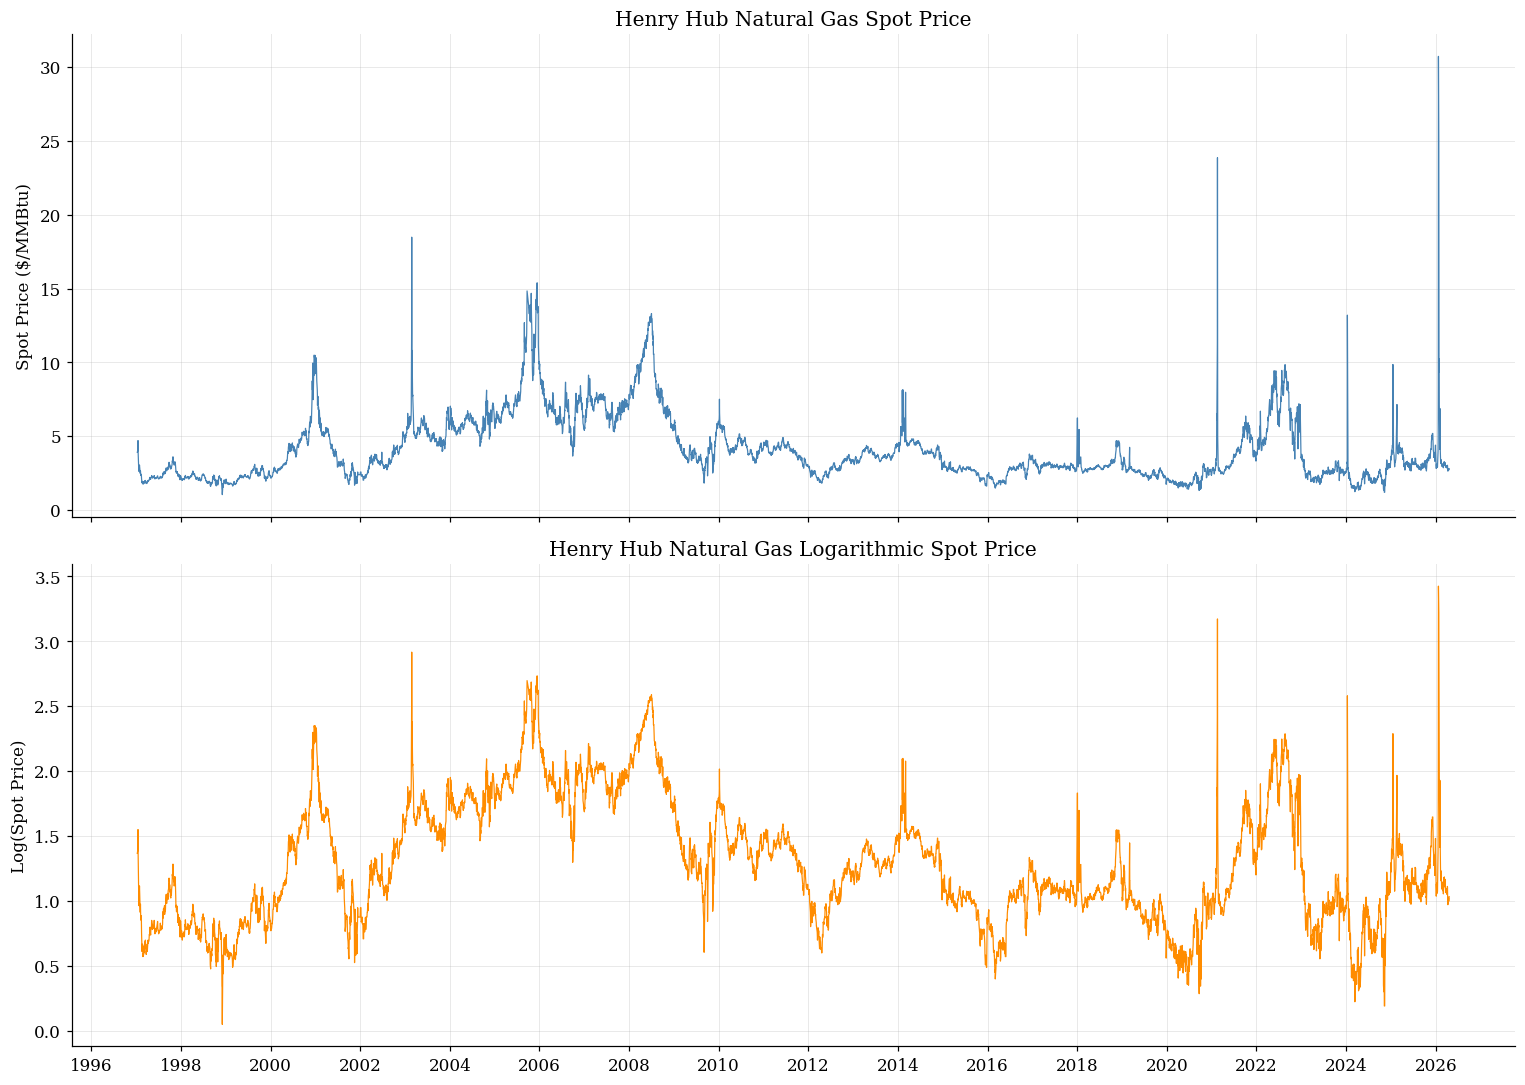

In [4]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
ax1.plot(df_natgas.index, df_natgas['price'], color='steelblue', lw=0.8, alpha=1)
ax1.set_ylabel("Spot Price ($/MMBtu)")
ax1.set_title("Henry Hub Natural Gas Spot Price")
ax1.grid(True)

ax2.plot(df_natgas.index, np.log(df_natgas['price']), color='darkorange', lw=0.8, alpha=1)
ax2.set_ylabel("Log(Spot Price)")
ax2.set_title("Henry Hub Natural Gas Logarithmic Spot Price")
ax2.grid(True)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

## Theoretical Aspect

We will not detail the proofs of the fundamental results here. The calculus is in the final report.

The goal is to model our latent states and to estimate them.

First, under the risk-neutral measure, our initial equations rewrite as:
$$
d\chi_t = (-\lambda_\chi - \zeta  \chi_t) dt + \sigma_\chi dZ_t^{\chi}
$$
$$
d\xi_t = (\mu_{\xi} -\lambda_\xi- \gamma \xi_t)dt + \sigma_\xi dZ_t^{\xi}
$$

Solving the two OU processes gives (here, the $\sigma_\chi, \sigma_\xi$ are considered constant so this is easier compared to the temperature modelling), $\forall u<t$:

$$
\chi_t = \chi_u e^{-\zeta (t-u)} - \frac{\lambda_\chi}{\zeta}(1 - e^{-\zeta (t-u)}) + \int_u^t e^{-\zeta (t-s)} \sigma_\chi dZ_s^{\chi}
$$

$$
\xi_t = \xi_u e^{-\gamma (t-u)} + \frac{\mu_{\xi} - \lambda_\xi}{\gamma}(1 - e^{-\gamma (t-u)}) + \int_u^t e^{-\gamma (t-s)} \sigma_\xi dZ_s^{\xi}
$$

By computation, with $u=0$:
$$\mathbb{E}^Q[\log(S_t)] =\mathbb{E}^Q[\chi_t]+\mathbb{E}^Q[\xi_t] = \chi_0 e^{-\zeta t}+ \xi_0 e^{-\gamma t}-\frac{\lambda_{\chi}}{\zeta}(1-e^{-\zeta t})+\frac{\mu_{\xi}-\lambda_{\xi}}{\gamma}(1-e^{-\gamma t})$$

$$\mathbb{V}[\log(S_t)] = \frac{\sigma_{\chi}^2}{2\zeta}(1-e^{-2\zeta t})+\frac{\sigma_{\xi}^2}{2\gamma}(1-e^{-2\gamma t})+2\frac{\sigma_{\chi}\sigma_{\xi}\rho_{\chi\xi}}{\zeta+\gamma}(1-e^{-(\zeta+\gamma)t})$$

**Proposition.** If $\log(S_t)$ is Gaussian, then $S_t$ is log-normal and its
expectation under the risk-neutral measure $\mathbb{Q}$ writes:

$$
\log \mathbb{E}^{\mathbb{Q}}[S_t] = \mathbb{E}^{\mathbb{Q}}[\log S_t] +
\frac{1}{2}\text{Var}^{\mathbb{Q}}[\log S_t]
$$

Substituting the decomposition $\log(S_t) = \chi_t + \xi_t$ and the moments
of the system under $\mathbb{Q}$, we obtain:

$$
\log \mathbb{E}^{\mathbb{Q}}[S_t] = \chi_0 e^{-\zeta t} + \xi_0 e^{-\gamma t} + A(t)
$$

where $A(t)$ aggregates the risk-neutral drift corrections and the variance contributions:

$$
A(t) = -\frac{\lambda_\chi}{\zeta}(1 - e^{-\zeta t}) +
\frac{\mu_\xi - \lambda_\xi}{\gamma}(1 - e^{-\gamma t}) +
\frac{1}{2}\left(\frac{1-e^{-2\zeta t}}{2\zeta}\sigma_\chi^2 +
\frac{1-e^{-2\gamma t}}{2\gamma}\sigma_\xi^2 +
2\frac{1-e^{-(\zeta+\gamma)t}}{\zeta+\gamma}\sigma_\chi\sigma_\xi\rho\right)
$$

The parameters $\lambda_\chi$ and $\lambda_\xi$ are the market risk premia
associated respectively with the short- and long-term factors, and
$(\chi_0, \xi_0)$ are the initial conditions of the latent states.

Moreover, by definition of a futures contract: $F(t,T) = \mathbb{E}^{\mathbb{Q}}_t[S_T]$. Hence:
$$
\log F(0,T) = \chi_0 e^{-\zeta T} + \xi_0 e^{-\gamma T} + A(T)
$$

We set $x_t=\begin{bmatrix}\chi_t\\\xi_t\end{bmatrix}$. With a time step $\Delta t=1 $:

$$
x_t = \begin{bmatrix}

e^{-\zeta} \chi_{t-1} - \frac{\lambda_\chi}{\zeta}(1-e^{-\zeta})+\omega^{\chi}_t
\\
e^{-\gamma} \xi_{t-1} + \frac{\mu_\xi - \lambda_\xi}{\gamma}(1-e^{-\gamma})+\omega^{\xi}_t\end{bmatrix}
$$
such that $\omega_t=\begin{bmatrix}\omega^{\chi}_t \\\omega^{\xi}_t\end{bmatrix} = \begin{bmatrix}\sigma_{\chi} \int^t_{t-1} e^{-\zeta (t-s)} dW^{\chi}_s \\\sigma_{\xi} \int^t_{t-1} e^{-\gamma (t-s)} dW^{\xi}_s\end{bmatrix}\sim \mathcal{N}(0, W)$ where the covariance matrix $W$ is given by:
$$W = \begin{bmatrix}
\frac{1-e^{-2\zeta}}{2\zeta}\sigma^2_\chi &
\frac{1-e^{-(\zeta+\gamma)}}{\zeta+\gamma}\sigma_\chi\sigma_\xi\rho_{\chi\xi} \\
\frac{1-e^{-(\zeta+\gamma)}}{\zeta+\gamma}\sigma_\chi\sigma_\xi\rho_{\chi\xi} &
\frac{1-e^{-2\gamma}}{2\gamma}\sigma^2_\xi
\end{bmatrix}$$

**Observation equation.** At each date $t$ we observe a vector of
$n$ futures log-prices $y_t = (\log F_{t,T_1}, \dots, \log F_{t,T_n})'$:

$$
y_t = d_t + F_t' x_t + v_t
$$

where
- the observation matrix $F_t \in \mathbb{R}^{2 \times n}$ is:

$$
F_t = \begin{bmatrix}
e^{-\zeta(T_1-t)} & \cdots & e^{-\zeta(T_n-t)} \\
e^{-\gamma(T_1-t)} & \cdots & e^{-\gamma(T_n-t)}
\end{bmatrix}
$$

- $d_t = (A(T_1-t), \dots, A(T_n-t))'$ is the vector of convexity terms
defined above
- $v_t \in \mathbb{R}^n$ is the measurement-error vector, defined such that
$v_t \sim \mathcal{N}(0, V)$ where $V = s^2 I_n$. The matrix $V$ is
diagonal: measurement errors are assumed independent and
homoscedastic across contracts.

## Futures Contracts

### Import Future Contracts 

We retrieve natural gas futures data from Databento, a historical financial-data platform offering free API access upon registration. To preserve our data quota, the data is downloaded once and then cached locally as CSV.

In [5]:
API_KEY = "XXXXXXXX"
# client = db.Historical(API_KEY)  # needs a Databento API key; cached CSV loaded below  

In [6]:
# Run ONCE only (Databento download)
"""
data = client.timeseries.get_range(
    dataset  = "GLBX.MDP3",
    symbols  = ["NG.c.0",  "NG.c.1",  "NG.c.2",
                "NG.c.3",  "NG.c.4",  "NG.c.5",
                "NG.c.6",  "NG.c.7",  "NG.c.8",
                "NG.c.9",  "NG.c.10", "NG.c.11"],
    schema   = "ohlcv-1d",
    start    = "2010-06-07",
    end      = "2024-04-05",
    stype_in = "continuous",
)
df_raw = data.to_df()
df_raw.to_csv("ng_futures_databento_raw.csv")
print(f"✓ Raw saved: {df_raw.shape}")

# Format and save final CSV
df_pivot = df_raw.pivot_table(
    index   = 'ts_event',
    columns = 'symbol',
    values  = 'close'
).rename(columns={f'NG.c.{i}': f'C{i+1}' for i in range(12)})
df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot = df_pivot.sort_index() / 1000  # cents to $/MMBtu
df_pivot.to_csv("ng_futures_databento.csv")
"""

'\ndata = client.timeseries.get_range(\n    dataset  = "GLBX.MDP3",\n    symbols  = ["NG.c.0",  "NG.c.1",  "NG.c.2",\n                "NG.c.3",  "NG.c.4",  "NG.c.5",\n                "NG.c.6",  "NG.c.7",  "NG.c.8",\n                "NG.c.9",  "NG.c.10", "NG.c.11"],\n    schema   = "ohlcv-1d",\n    start    = "2010-06-07",\n    end      = "2024-04-05",\n    stype_in = "continuous",\n)\ndf_raw = data.to_df()\ndf_raw.to_csv("ng_futures_databento_raw.csv")\nprint(f"✓ Raw saved: {df_raw.shape}")\n\n# Format and save final CSV\ndf_pivot = df_raw.pivot_table(\n    index   = \'ts_event\',\n    columns = \'symbol\',\n    values  = \'close\'\n).rename(columns={f\'NG.c.{i}\': f\'C{i+1}\' for i in range(12)})\ndf_pivot.index = pd.to_datetime(df_pivot.index)\ndf_pivot = df_pivot.sort_index() / 1000  # cents to $/MMBtu\ndf_pivot.to_csv("ng_futures_databento.csv")\n'

In [7]:
df_futures = pd.read_csv("ng_futures_databento.csv")
df_futures.index = pd.to_datetime(df_futures["ts_event"]).dt.tz_localize(None)
df_futures = df_futures.drop(columns=['ts_event'])

df_futures.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12
ts_event,,,,,,,,,,,,
2010-06-07,4.980,5.031,5.069,5.140,5.365,5.650,5.822,5.769,5.644,5.392,5.382,5.422
2010-06-08,4.799,4.856,4.894,4.994,5.246,5.521,5.699,5.646,5.522,5.289,5.304,5.359
2010-06-09,4.672,4.728,4.787,4.870,5.171,5.480,5.657,5.612,5.494,5.263,5.281,5.333
2010-06-10,4.686,4.751,4.803,4.883,5.172,5.477,5.674,5.628,5.500,5.270,5.287,5.329
2010-06-11,4.793,4.846,4.899,4.969,5.227,5.515,5.686,5.626,5.510,5.265,5.278,5.325


We thus have 12 daily futures contracts between June 2010 and April 2024, denoted $C_1, C_2, \ldots, C_{12}$. The contract number indicates its relative maturity: $C_1$ is the contract closest to expiry, called the *front-month*, and $C_{12}$ is the one delivering in 12 months.

These are **rolling** contracts: at each expiry date, $C_1$ is replaced by what was $C_2$, $C_2$ by $C_3$, and so on. A new contract $C_{12}$ is then issued for the corresponding month. Thus at each date $t$ we always observe exactly 12 active contracts, whose residual maturities $\tau_i(t) = T_i(t) - t$ vary continuously over time and jump at each roll.

The goal here is therefore to determine these $\tau_i(t)$ for each contract over time. By NYMEX convention, natural gas contracts expire on the **3rd business day before the 1st of the delivery month**.

By identifying the delivery month of $C_1$, we deduce the maturities of the other contracts: $\tau_i(t) = \frac{T_i(t) - t}{365.25} \quad \text{in years}$

|Contract | mean $\tau_i$ | max $\tau_i$ |
|---------|---------------|-------------|
| C1      | 0.033 yr      | 0.25 yr     |
| C6      | 0.49 yr       | 0.74 yr     |
| C12     | 0.95 yr       | 0.99 yr     |

In [8]:
def get_nymex_expiry(year, month):
    first_of_month = pd.Timestamp(year=year, month=month, day=1)
    return first_of_month - 3 * BDay()

def get_front_month(t):
    """Delivery month of contract C1 at date t"""
    expiry_current = get_nymex_expiry(t.year, t.month)
    if t <= expiry_current:
        return t.year, t.month
    else:
        m = t.month + 1
        y = t.year + (m - 1) // 12
        m = ((m - 1) % 12) + 1
        return y, m

def compute_tau_dataframe(dates, n_contracts=12):
    """
    For each date t, compute tau_1(t),...,tau_12(t) in years
    """
    records = []
    for t in dates:
        front_year, front_month = get_front_month(t)
        row = {'date': t}
        for i in range(1, n_contracts + 1):
            # Delivery month of contract Ci
            m = front_month + (i - 1)
            y = front_year + (m - 1) // 12
            m = ((m - 1) % 12) + 1
            expiry = get_nymex_expiry(y, m)
            tau = max((expiry - t).days / 365.25, 1/365.25)
            row[f'tau{i}'] = tau
        records.append(row)
    
    df_tau = pd.DataFrame(records).set_index('date')
    return df_tau

In [9]:
df_tau = compute_tau_dataframe(df_futures.index)
df_tau.head()

,tau1,tau2,tau3,tau4,tau5,tau6,tau7,tau8,tau9,tau10,tau11,tau12
date,,,,,,,,,,,,
2010-06-07,0.057495,0.139630,0.221766,0.309377,0.388775,0.470910,0.561259,0.640657,0.717317,0.807666,0.887064,0.969199
2010-06-08,0.054757,0.136893,0.219028,0.306639,0.386037,0.468172,0.558522,0.637919,0.714579,0.804928,0.884326,0.966461
2010-06-09,0.052019,0.134155,0.216290,0.303901,0.383299,0.465435,0.555784,0.635181,0.711841,0.802190,0.881588,0.963723
2010-06-10,0.049281,0.131417,0.213552,0.301164,0.380561,0.462697,0.553046,0.632444,0.709103,0.799452,0.878850,0.960986
2010-06-11,0.046543,0.128679,0.210815,0.298426,0.377823,0.459959,0.550308,0.629706,0.706366,0.796715,0.876112,0.958248


### Data Analysis: Contango & Backwardation

First, we put our three dataframes `df_natgas`, `df_futures`, `df_tau` on the same time scale:

In [10]:
common_idx = df_futures.index\
    .intersection(df_tau.index)\
    .intersection(df_natgas.index)

df_futures   = df_futures.loc[common_idx]
df_tau   = df_tau.loc[common_idx]
df_natgas = df_natgas.loc[common_idx]

print(f"Common period: {common_idx[0].date()} → {common_idx[-1].date()}")
print(f"Observations    : {len(common_idx)}")

Common period: 2010-06-07 → 2024-04-04
Observations    : 3485


In [11]:
def plot_futures_log(df_futures, df_natgas, window=None):
    """
    Plot the spot and futures C1-C12 log-prices
    window : number of last days to display (None = all)
    """
    common = df_natgas.index.intersection(df_futures.index)
    
    if window is not None:
        common = common[-window:]

    spot = np.log(df_natgas.loc[common, 'price'])

    groups = {
        'Short term  C1-C4'  : ['C1','C2','C3','C4'],
        'Medium term  C5-C8'  : ['C5','C6','C7','C8'],
        'Long term   C9-C12' : ['C9','C10','C11','C12'],
    }

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(
        f"Henry Hub Spot & Futures C1-C12 (log) "
        f"{'(' + str(window) + ' last days)' if window else '(full period)'}",
        fontsize=12, fontweight='bold'
    )

    for ax, (title, cols), cmap in zip(
        axes, groups.items(),
        [plt.cm.Reds, plt.cm.Oranges, plt.cm.Blues]
    ):
        colors = cmap(np.linspace(0.4, 0.9, 4))
        for col, color in zip(cols, colors):
            idx = df_futures.index.intersection(common)
            ax.plot(idx, np.log(df_futures.loc[idx, col]),
                    lw=0.6, alpha=0.8, color=color, label=col)
        ax.plot(common, spot, color='black', lw=0.8,
                alpha=0.7, label='Spot', zorder=10)
        ax.set_ylabel("ln($/MMBtu)")
        ax.set_title(title)
        ax.legend(ncol=5, fontsize=8)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.show()

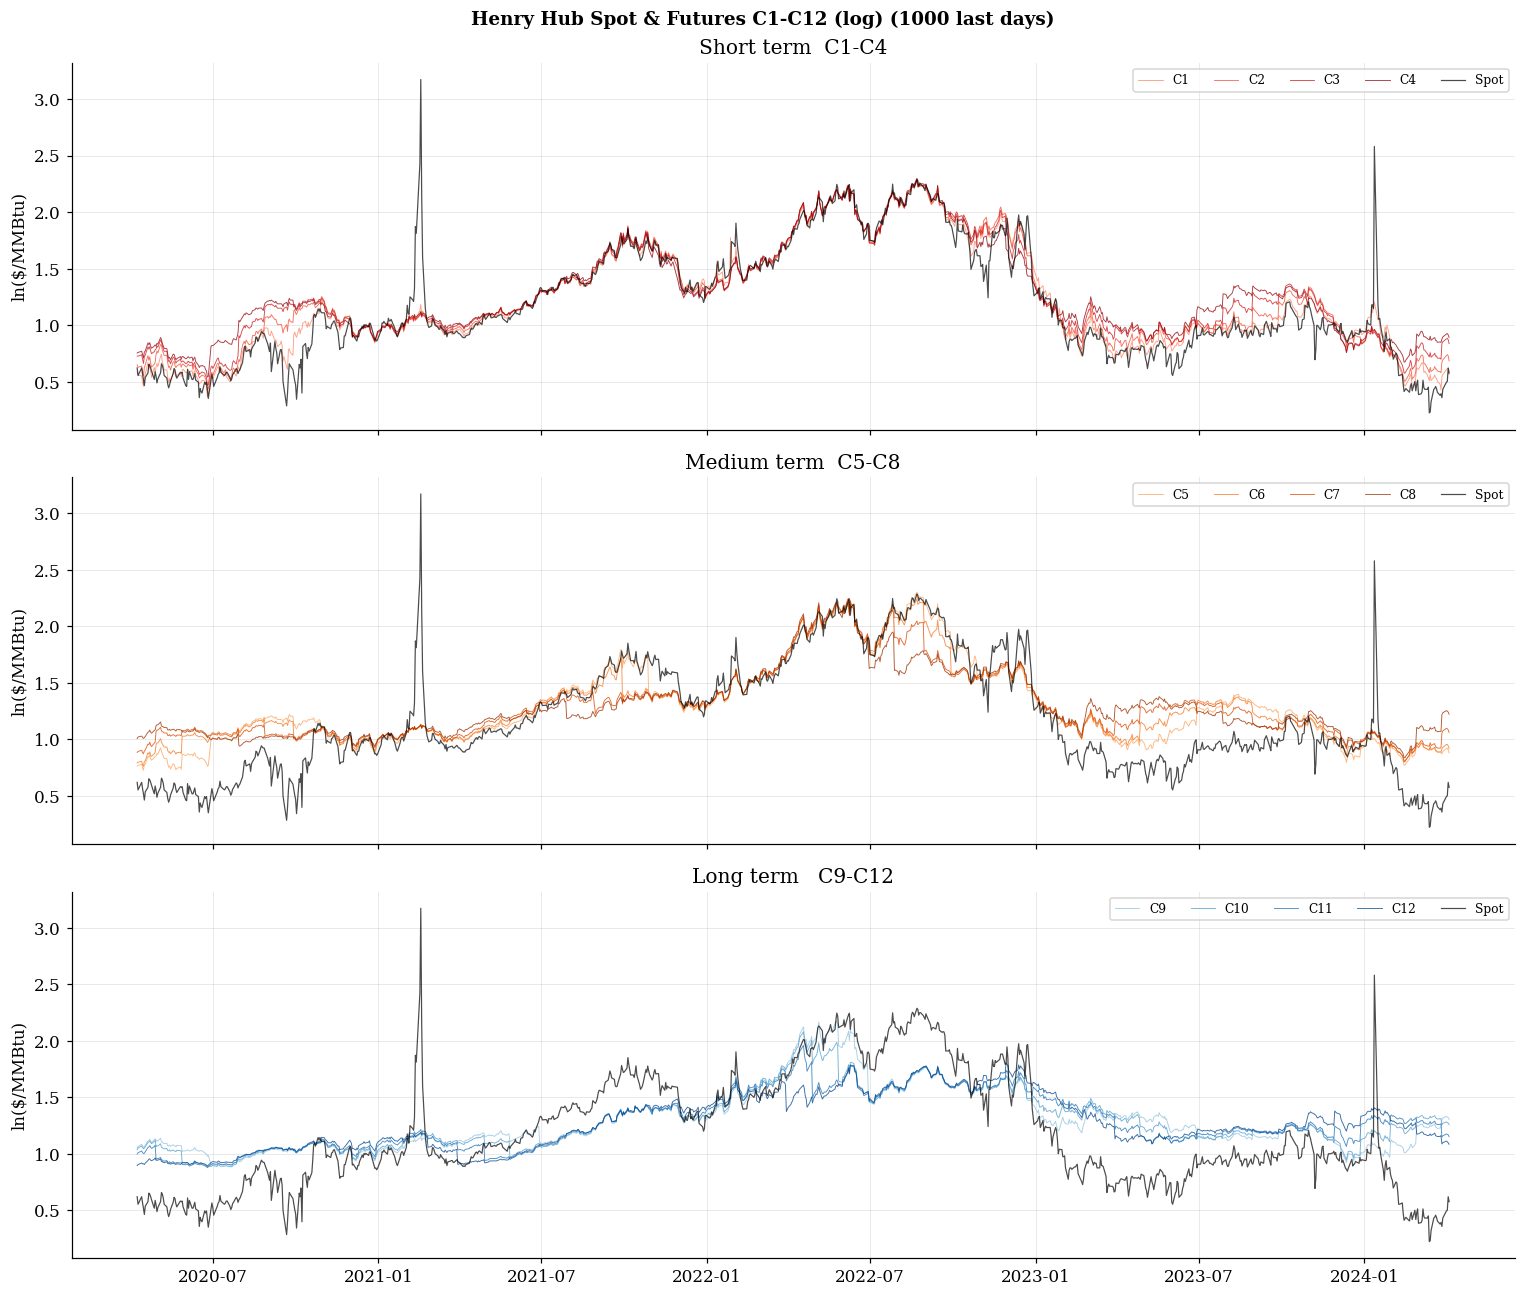

In [12]:
plot_futures_log(df_futures, df_natgas, window=1_000)

We notice that futures price volatility is higher when the contract maturity is close: this is known as the Samuelson effect. It can be explained by the fact that short-term contracts are more influenced by immediate supply-demand imbalances, while longer-maturity contracts anticipate transitory (non-permanent) shocks.

In [13]:
TRADING_DAYS = 252 
for contract in df_futures.columns:
    log_returns = np.log(df_futures[contract] / df_futures[contract].shift(1))
    # 2. Annualized historical volatility: std of returns times square root of time
    vol_annualized = log_returns.std() * np.sqrt(TRADING_DAYS)
    print(f"{contract:4} : {vol_annualized * 100:.2f} %")

C1   : 53.90 %
C2   : 47.11 %
C3   : 44.01 %
C4   : 42.45 %
C5   : 38.30 %
C6   : 36.74 %
C7   : 34.21 %
C8   : 33.09 %
C9   : 31.09 %
C10  : 29.80 %
C11  : 28.32 %
C12  : 26.65 %


Let us analyse the basis between a few contracts and the NatGas spot price to observe contango or backwardation regimes:

In [14]:
def plot_and_get_basis(df_futures, df_natgas, contract='C1', window=None, use_log=False):
    common = df_natgas.index.intersection(df_futures.index)
    if window is not None:
        common = common[-window:]

    spot   = df_natgas.loc[common, 'price']
    future = df_futures.loc[common, contract]

    if use_log:
        spot   = np.log(spot)
        future = np.log(future)
        unit        = "ln($/MMBtu)"
        basis_title = f"Log-Basis: ln({contract}) minus ln(Spot)"
    else:
        unit        = "$/MMBtu"
        basis_title = f"Nominal basis: {contract} minus Spot"

    basis = future - spot

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(
        f"Contango / Backwardation: Spot vs {contract} "
        f"{'(' + str(window) + ' last days)' if window else ''}",
        fontsize=12, fontweight='bold'
    )

    ax.plot(common, basis, color='purple', lw=0.8, label='Basis')
    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.fill_between(common, 0, basis,
                    where=(basis > 0), color='green', alpha=0.2,
                    label='Contango ($F_t > S_t$)')
    ax.fill_between(common, 0, basis,
                    where=(basis < 0), color='red', alpha=0.2,
                    label='Backwardation ($F_t < S_t$)')

    pct_contango = (basis > 0).mean() * 100
    ax.text(0.02, 0.92, f"Contango : {pct_contango:.1f}% | Backwardation : {100-pct_contango:.1f}%",
            transform=ax.transAxes, fontsize=9)

    ax.set_ylabel(unit)
    ax.set_title(basis_title)
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate(rotation=45)

    plt.tight_layout()
    plt.show()

    return basis

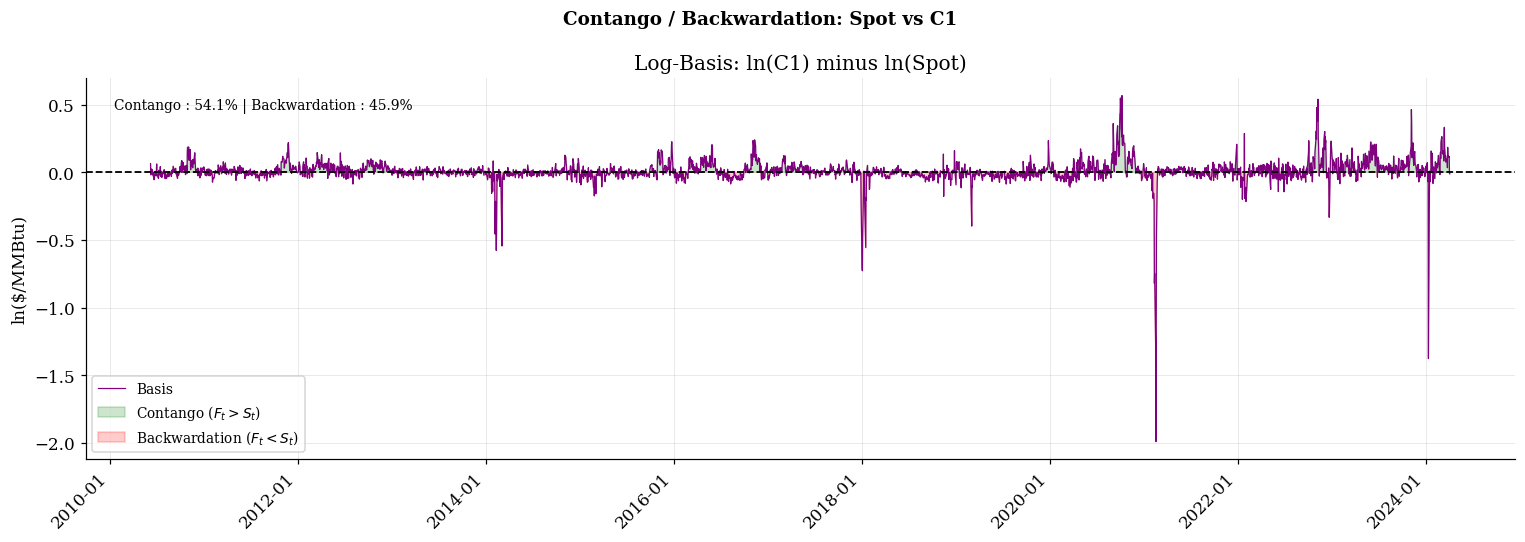

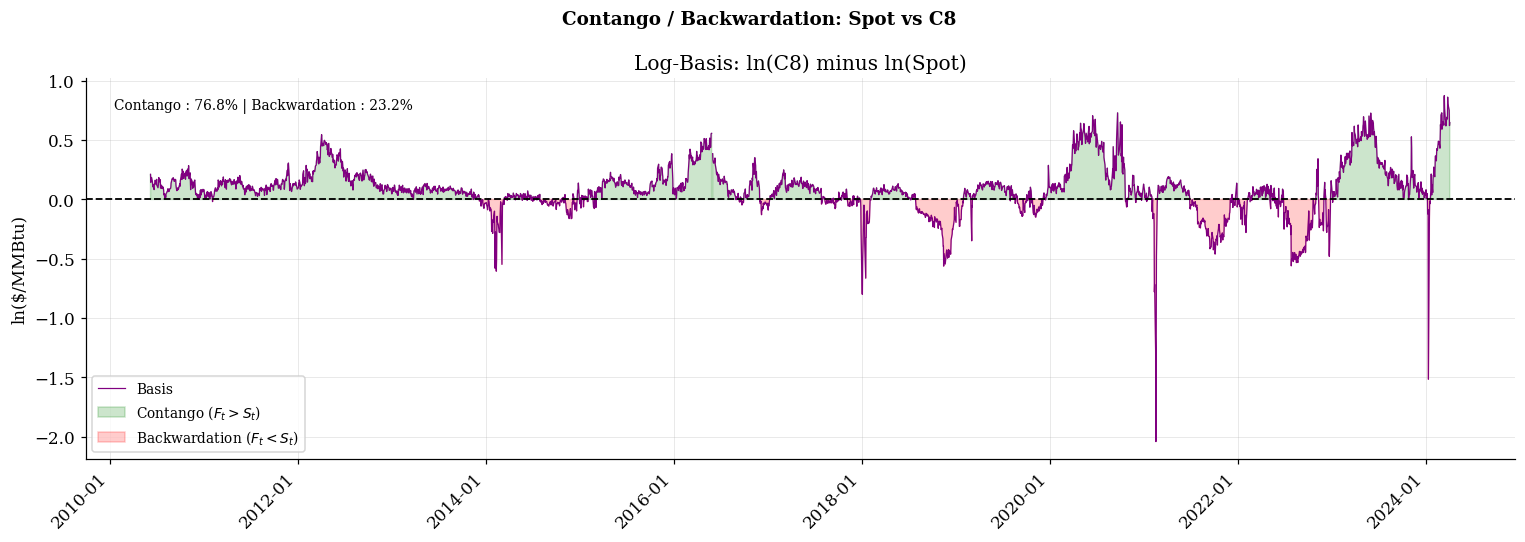

2010-06-07    0.211340
2010-06-08    0.143755
2010-06-09    0.166763
2010-06-10    0.184456
2010-06-11    0.184101
                ...   
2024-03-28    0.804270
2024-04-01    0.760350
2024-04-02    0.749699
2024-04-03    0.621559
2024-04-04    0.647162
Length: 3485, dtype: float64

In [15]:
plot_and_get_basis(df_futures, df_natgas, contract='C1', window=None, use_log=True)
plot_and_get_basis(df_futures, df_natgas, contract='C8', window=None, use_log=True)

**C1 (front-month)**: the basis oscillates almost symmetrically around 0 (54% contango / 46% backwardation) with violent backwardation spikes during demand shocks (Polar Vortex 2014, 2018 crisis, Texas Freeze 2021). Despite these violent shocks, the basis reverts to 0 very quickly: C1 directly absorbs the shocks of χ_t.

**C8 (8 months)**: contango dominates here, 77% of the time. The basis is positive under normal conditions (the 6-month storage cost is mechanically reflected in F_t > S_t). Backwardation episodes are rare and correspond to the most extreme shocks.


These different behaviours empirically confirm the decomposition $\ln(S_t) = \chi_t + \xi_t$: χ_t dominates the behaviour of C1 by absorbing transitory shocks, while ξ_t drives the equilibrium level toward which longer-maturity futures converge.

## Kalman Filter

We set $n$ the number of contracts available (12 here).
$$c = \begin{pmatrix} 0 \\ \frac{\mu_\xi}{\gamma} (1 - e^{-\gamma}) \end{pmatrix} \qquad G = \begin{pmatrix} e^{-\zeta} & 0 \\ 0 & e^{-\gamma} \end{pmatrix} \qquad y_t = \begin{pmatrix} \log F(t, T_1) \\ ... \\\log F(t, T_n) \end{pmatrix}$$

**Kalman quantities:**
* $a_{t|t-1} = \mathbb{E}[x_t | \mathcal{F}_{t-1}] \in \mathbb{R}^2 \quad$ state predicted before $y_t$.
* $a_t = \mathbb{E}[x_t | \mathcal{F}_t] \in \mathbb{R}^2 \quad$ state updated after observing $y_t$.
* $P_{t|t-1} = \text{Cov}(x_t | \mathcal{F}_{t-1}) \quad 2 \times 2 \quad$ uncertainty of $x_t$ before $y_t$.
* $P_t = \text{Cov}(x_t | \mathcal{F}_t) \quad 2 \times 2 \quad$ uncertainty of $x_t$ after $y_t$.
* $Z_{t|t-1} = \text{Cov}(e_t | \mathcal{F}_{t-1}) \quad M \times M \quad$ uncertainty on $y_t$.

 $\mathcal{F}_t = \sigma(y_1, \ldots, y_t)$ the canonical filtration.

### Problem overview 

As stated above, here is our system, with the first equation called the `state equation` (describing the dynamics of our latent states) and the second the `observation equation` (relating our observations to what we actually measure through the futures contracts):

$$\begin{cases}
x_t = c + G x_{t-1} + w_t \\
y_t = d_t + F'_t x_t + v_t
\end{cases}$$

We also set the full parameter vector to estimate, defined above: $$\theta = (\zeta, \gamma, \mu_\xi, \sigma_\chi, \sigma_\xi, \rho, \lambda_\xi, \lambda_\chi, s)$$

In our case the problem is twofold:
- the latent states $x_t$ are not observable, and we must simultaneously estimate the parameters $\theta$.

The Kalman filter solves this problem: it is a recursive algorithm on a linear Gaussian system that estimates the latent states.
Moreover, under the assumptions:
- $H_1$: linear system
- $H_2$: Gaussian noise for $\omega_t$ and $v_t$
- $H_3$: independence of the noises and no autocorrelation over time
- $H_4$: system initialization

then **the system is said to be optimal**.

Here are the steps of the Kalman filter.


We initialize $a_0 = \mathbb{E}[x_0] = \begin{bmatrix} 0 \\ \frac{\mu_\xi}{\gamma} \end{bmatrix}$ and $P_0 = Cov(x_0) = \begin{pmatrix}
\frac{\sigma_\chi^2}{2\zeta} & \frac{\sigma_\chi \sigma_\xi \rho_{\chi\xi}}{\zeta + \gamma} \\[1ex]
\frac{\sigma_\chi \sigma_\xi \rho_{\chi\xi}}{\zeta + \gamma} & \frac{\sigma_\xi^2}{2\gamma}
\end{pmatrix}.$

$$x_0 \sim N(a_0, P_0)$$

**Step 1** (Initialization of $a_0$ and $P_0$)

For t = $1$ to $n_T$ (number of time observations):
**Step 2** (Prediction / time update). We predict $x_t$ before observing $y_t$

$$a_{t|t-1} = G a_{t-1} + c$$

$$P_{t|t-1} = G P_{t-1} G' + W$$






**Step 3** *(Receive the new observation $y_t$)* We measure the observation error

$$e_t = y_t - d_t - F'_t a_{t|t-1}$$

$$L_{t|t-1} = F'_t P_{t|t-1} F_t + V$$

**Step 4** Compute the log-likelihood at $t$:

$$\ell_t (\theta, y_t)= -\frac{1}{2} \left( e_t' L_{t|t-1}^{-1} e_t + \log |L_{t|t-1}| \right)$$

**Step 5** (Correction / measurement update). Here the Kalman gain is the quantity that minimizes the mean squared error of $x_t - a_t$

$$K_t = P_{t|t-1} F_t (L_{t|t-1})^{-1}$$

$$a_t = a_{t|t-1} + K_t e_t$$

$$P_t = (I - K_t F'_t) P_{t|t-1}$$

Finally we compute the likelihood for our parameters $\theta$:

$$\ell(\theta, y) = \frac{1}{n_T} \sum_{t=1}^{n_T}
\ell_t(\theta, y_t)$$

### Computation

**Temporal split:** we estimate our parameters on 2010 to 2018 (train) and test them on
2019 to 2024 (test). This lets us see how the latent states behave on unseen data.

In [16]:
# ============================================================
# Load the data and prepare the split
# ============================================================
train_end  = '2018-12-31'
test_start = '2019-01-01'

common_idx     = df_futures.index.intersection(df_tau.index)
df_fut_aligned = df_futures.loc[common_idx]
df_tau_aligned = df_tau.loc[common_idx]

mask_train = df_fut_aligned.index <= train_end
mask_test  = df_fut_aligned.index >= test_start

# Daily arrays
log_fut_train_daily = np.log(df_fut_aligned[mask_train].values).astype(np.float64)
taus_train_daily    = df_tau_aligned[mask_train].values.astype(np.float64)
idx_train           = df_fut_aligned[mask_train].index

log_fut_test_daily  = np.log(df_fut_aligned[mask_test].values).astype(np.float64)
taus_test_daily     = df_tau_aligned[mask_test].values.astype(np.float64)
idx_test            = df_fut_aligned[mask_test].index

# Weekly arrays for MLE
df_fut_train_w = df_fut_aligned[mask_train].resample('W-FRI').last().dropna()
df_tau_train_w = df_tau_aligned[mask_train].resample('W-FRI').last().dropna()
common_w       = df_fut_train_w.index.intersection(df_tau_train_w.index)

log_futures_weekly = np.log(df_fut_train_w.loc[common_w].values).astype(np.float64)
taus_weekly        = df_tau_train_w.loc[common_w].values.astype(np.float64)

print(f"Train : {idx_train[0].date()} → {idx_train[-1].date()} ({len(idx_train)} obs)")
print(f"Test  : {idx_test[0].date()}  → {idx_test[-1].date()}  ({len(idx_test)} obs)")
print(f"Weekly train: {len(log_futures_weekly)} obs")

Train : 2010-06-07 → 2018-12-28 (2169 obs)
Test  : 2019-01-02  → 2024-04-04  (1316 obs)
Weekly train: 447 obs


We run the MLE from 4 starting points with economically motivated bounds.

The theoretical half-life of each factor guides the choice of bounds. We look for $t^*$ such that $\exp(-\zeta t^*) = 1/2$, knowing that $\mathbb{E}[\chi_t|\chi_0] = \chi_0 e^{-\zeta t}$.

$$\text{half-life}(\chi_t) = \frac{\ln 2}{\zeta} \in [2 \text{ weeks},
6 \text{ months}] \implies \zeta \in [1.4, 18]$$

$$\text{half-life}(\xi_t) = \frac{\ln 2}{\gamma} \in [2 \text{ years},
20 \text{ years}] \implies \gamma \in [0.035, 0.35]$$

In [17]:
def run_mle(log_futures, taus, theta0_list, bounds, max_iter=500):
    """
    Run the MLE from several starting points.
    Return the best result plus convergence histories.
    """
    best_nll    = np.inf
    best_result = None
    best_hist   = None
    all_histories = []
    param_names     = ['zeta', 'gamma', 'mu_xi',
                       'sigma_chi', 'sigma_xi', 'rho', 's2']

    for i, theta0 in enumerate(theta0_list):
        nll_hist    = []
        params_hist = []

        def objective(params):
            nll = neg_log_lik(params, log_futures, taus)
            nll_hist.append(nll)
            params_hist.append(params.copy())
            pbar.set_postfix({'NLL': f'{nll:.4f}', 'iter': len(nll_hist)})
            pbar.update(1)
            return nll

        with tqdm(total=max_iter,
                  desc=f"Init {i+1}/{len(theta0_list)}",
                  ncols=90) as pbar:
            result = minimize(
                objective,
                x0      = theta0,
                method  = 'L-BFGS-B',
                bounds  = bounds,
                options = {'maxiter': max_iter,
                           'ftol'   : 1e-10,
                           'gtol'   : 1e-7,
                           'eps'    : 1e-7}
            )

        all_histories.append({
            'nll_hist'    : nll_hist,
            'params_hist' : params_hist,
            'result'      : result,
            'theta0'      : theta0
        })

        print(f"  Init {i+1} → NLL = {result.fun:.6f} | "
              f"converged = {result.success} | iter = {len(nll_hist)}")

        if result.fun < best_nll:
            best_nll    = result.fun
            best_result = result
            best_hist   = all_histories[-1]

    print(f"\n✓ Best NLL : {best_nll:.6f}")
    return best_result, best_hist, all_histories, param_names


In [18]:
def print_results(best_result, param_names):
    params = best_result.x
    print("\n" + "="*52)
    print("  ESTIMATED PARAMETERS: Schwartz-Smith")
    print("="*52)
    for name, val in zip(param_names, params):
        print(f"  {name:<14} : {val:>10.6f}")
    print(f"  {'lambda_chi':<14} : {'0.0':>10}  (fixed)")
    print(f"  {'lambda_xi':<14} : {'0.0':>10}  (fixed)")
    print("="*52)
    print(f"  Final NLL      : {best_result.fun:>10.6f}")
    print(f"  Converged      : {best_result.success}")
    print(f"  Message        : {best_result.message}")
    print(f"  Ratio ζ/γ      : {params[0]/params[1]:>10.2f}  (>> 1 required)")
    print("="*52)

In [19]:
theta0_list = [
    [3.0,  0.10,  0.5,  0.40,  0.10, -0.30,  0.01],
    [5.0,  0.07,  1.0,  0.50,  0.15, -0.50,  0.01],
    [8.0,  0.15,  0.3,  0.35,  0.08, -0.20,  0.02],
    [12.0, 0.05,  0.8,  0.45,  0.12, -0.40,  0.01],
]

# widen the search ranges to avoid boundary solutions
bounds = [
    (0.5,  50.0),    # zeta
    (0.001, 1.0),    # gamma
    (-5.0,  5.0),    # mu_xi
    (0.01,  3.0),    # sigma_chi
    (0.001, 1.0),    # sigma_xi
    (-0.98, 0.98),   # rho
    (1e-6,  1.0),    # s2
]

best_result, best_hist, all_histories, param_names = run_mle(
    log_futures_weekly, taus_weekly, theta0_list, bounds
)
best_result = min(all_histories, key=lambda x: x['result'].fun)['result']
best_hist   = min(all_histories, key=lambda x: x['result'].fun)
print_results(best_result, param_names)


Init 1/4:   0%|                                                   | 0/500 [00:00<?, ?it/s]


Init 1/4:   0%|                             | 0/500 [00:00<?, ?it/s, NLL=-15.0526, iter=1]


Init 1/4:   0%|                     | 1/500 [00:00<01:07,  7.37it/s, NLL=-15.0526, iter=2]


Init 1/4:   0%|                     | 2/500 [00:00<00:34, 14.64it/s, NLL=-15.0526, iter=2]


Init 1/4:   0%|                     | 2/500 [00:00<00:34, 14.64it/s, NLL=-15.0526, iter=3]

...


Init 4/4: 1454it [01:49, 13.77it/s, NLL=-30.7392, iter=1455]


Init 4/4: 1455it [01:49, 13.82it/s, NLL=-30.7392, iter=1455]


Init 4/4: 1455it [01:49, 13.82it/s, NLL=-30.7392, iter=1456]


Init 4/4: 1456it [01:49, 13.26it/s, NLL=-30.7392, iter=1456]

  Init 4 → NLL = -30.739159 | converged = True | iter = 1456

✓ Best NLL : -30.739159

  ESTIMATED PARAMETERS: Schwartz-Smith
  zeta           :   1.402997
  gamma          :   0.001726
  mu_xi          :   0.002172
  sigma_chi      :   0.331469
  sigma_xi       :   0.019440
  rho            :  -0.112194
  s2             :   0.001417
  lambda_chi     :        0.0  (fixed)
  lambda_xi      :        0.0  (fixed)
  Final NLL      : -30.739159
  Converged      : True
  Message        : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  Ratio ζ/γ      :     813.03  (>> 1 required)


Whatever the initialization, the parameters converge to:
- $\zeta \approx 1.4$ (near its lower bound)
- $\gamma \approx 0.005$ (near its lower bound)

This suggests the optimizer does not find an interior minimum for these parameters.

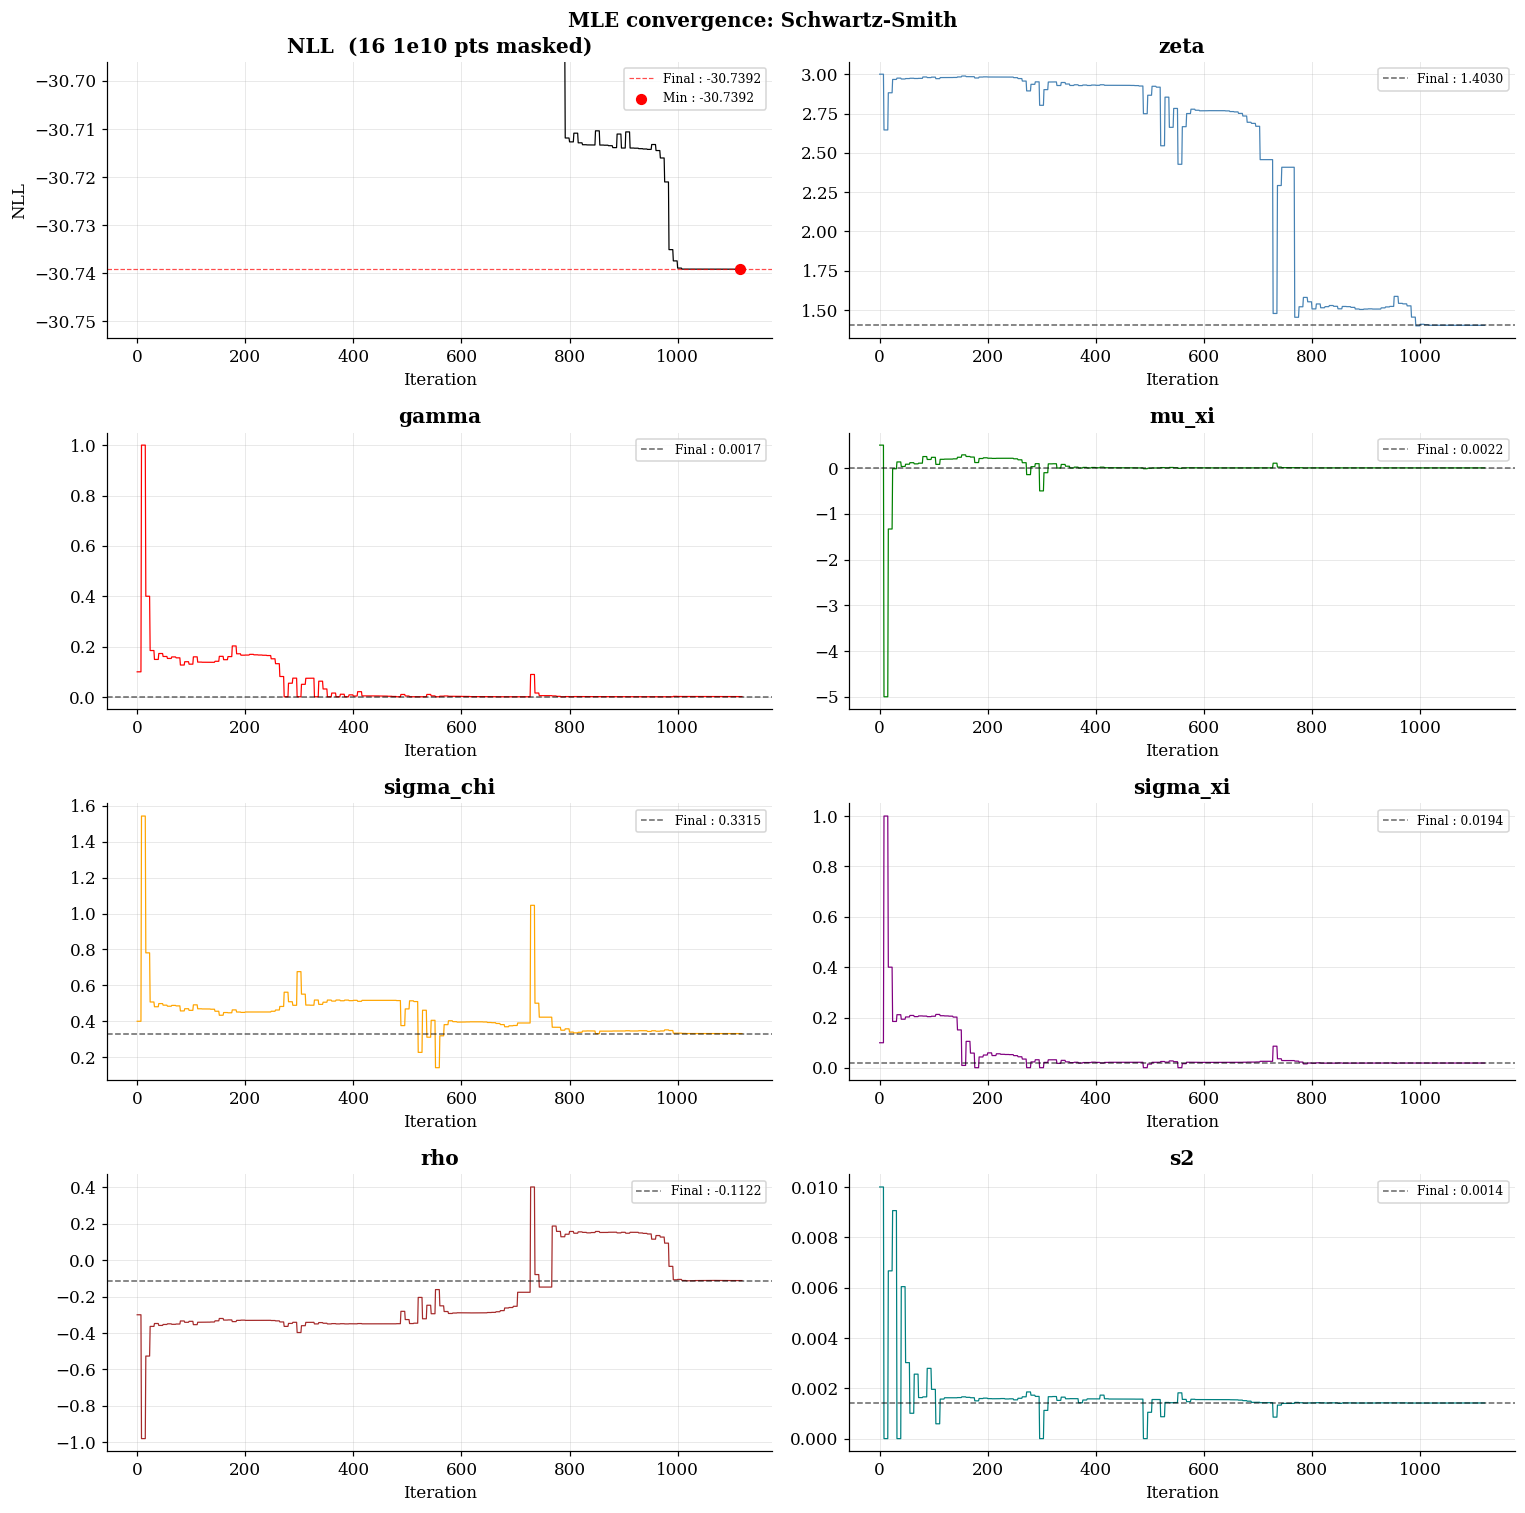

In [20]:
def plot_convergence(best_hist, param_names):
    nll_hist    = best_hist['nll_hist']
    params_hist = best_hist['params_hist']

    # Filter out the 1e10 values for the NLL
    nll_arr     = np.array(nll_hist)
    valid_mask  = nll_arr < 1e9
    nll_valid   = nll_arr[valid_mask]
    iters_valid = np.where(valid_mask)[0]

    fig, axes = plt.subplots(4, 2, figsize=(14, 14))
    fig.suptitle("MLE convergence: Schwartz-Smith",
                 fontsize=13, fontweight='bold')

    # NLL: full series plus zoom on finite values
    ax = axes[0, 0]
    if len(nll_valid) > 0:
        ax.plot(iters_valid, nll_valid, color='black', lw=0.8)
        # Annotate the minimum
        idx_min = np.argmin(nll_valid)
        ax.axhline(nll_valid[-1], color='red', lw=0.8,
                   linestyle='--', alpha=0.7,
                   label=f'Final : {nll_valid[-1]:.4f}')
        ax.scatter(iters_valid[idx_min], nll_valid[idx_min],
                   color='red', s=40, zorder=5,
                   label=f'Min : {nll_valid[idx_min]:.4f}')
        # Automatic zoom on the last quarter of the convergence
        n_zoom      = max(len(nll_valid) // 4, 10)
        nll_zoom    = nll_valid[-n_zoom:]
        margin      = (nll_zoom.max() - nll_zoom.min()) * 0.1 + 1e-6
        ax.set_ylim(nll_zoom.min() - margin * 5,
                    nll_zoom.max() + margin * 5)
        n_invalid   = valid_mask.sum() - len(valid_mask)
        ax.set_title(f"NLL  ({(~valid_mask).sum()} 1e10 pts masked)",
                     fontweight='bold')
    else:
        ax.set_title("NLL: no finite value", fontweight='bold')

    ax.set_xlabel("Iteration")
    ax.set_ylabel("NLL")
    ax.legend(fontsize=8)

    # Parameters: also filter the steps where NLL=1e10
    positions = [(0,1),(1,0),(1,1),(2,0),(2,1),(3,0),(3,1)]
    colors    = ['steelblue','red','green','orange','purple','brown','teal']

    for (r, c), name, color in zip(positions, param_names, colors):
        all_vals  = np.array([p[param_names.index(name)]
                              for p in params_hist])
        # Show only the iterations with finite NLL
        vals      = all_vals[valid_mask]
        iters_p   = iters_valid

        if len(vals) == 0:
            axes[r, c].set_title(f"{name}: no value", fontweight='bold')
            continue

        axes[r, c].plot(iters_p, vals, color=color, lw=0.8)
        axes[r, c].axhline(vals[-1], color='black', lw=1.0,
                           linestyle='--', alpha=0.6,
                           label=f'Final : {vals[-1]:.4f}')
        axes[r, c].set_title(name, fontweight='bold')
        axes[r, c].set_xlabel("Iteration")
        axes[r, c].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_convergence(best_hist, param_names)

**Analysis of the observation matrix $F_t$**

The observation matrix $F_t \in \mathbb{R}^{2 \times 12}$ writes:

$$F_t = \begin{bmatrix}
e^{-\zeta \tau_1} & \cdots & e^{-\zeta \tau_{12}} \\
e^{-\gamma \tau_1} & \cdots & e^{-\gamma \tau_{12}}
\end{bmatrix}$$

To separate $\chi_t$ from $\xi_t$, the Kalman filter requires these
two rows to be sufficiently distinct. With $\gamma \approx 0.005$
and $\tau_{\max} \approx 1$ year:

$$e^{-\gamma \tau_i} = e^{-0.005 \times \tau_i} \in [0.9950, 0.9997]$$

**The second row is nearly constant**, it is $\approx 1$ for
all maturities. The filter cannot distinguish $\xi_t$ from a
time constant.

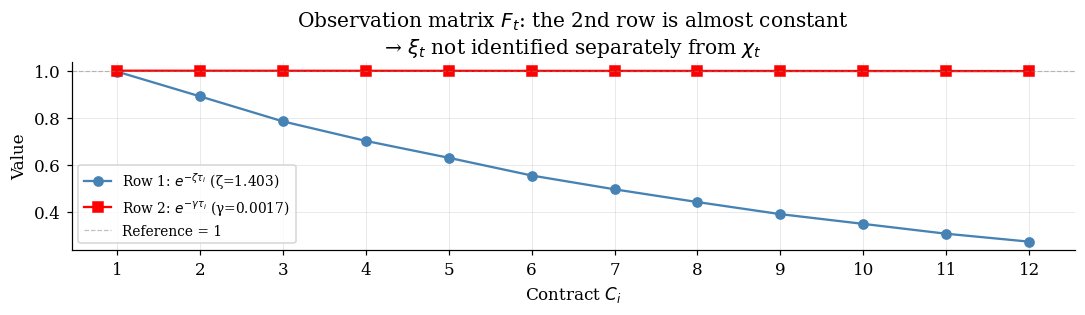

Row 2 (γ) min: 0.99841  max: 1.00000
Total variation   : 0.00158  ← almost zero


In [21]:
# ============================================================
# Numerical illustration of F_t with the estimated parameters
# ============================================================
p         = best_result.x
zeta_opt  = p[0]
gamma_opt = p[1]

taus_ex = df_tau_aligned.iloc[100].values 

Ft_opt = np.array([
    np.exp(-zeta_opt  * taus_ex),
    np.exp(-gamma_opt * taus_ex)
])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, 13), Ft_opt[0], 'o-', color='steelblue', lw=1.5,
        label=f'Row 1: $e^{{-\\zeta \\tau_i}}$ (ζ={zeta_opt:.3f})')
ax.plot(range(1, 13), Ft_opt[1], 's-', color='red', lw=1.5,
        label=f'Row 2: $e^{{-\\gamma \\tau_i}}$ (γ={gamma_opt:.4f})')
ax.axhline(1.0, color='gray', lw=0.8, linestyle='--', alpha=0.5,
           label='Reference = 1')
ax.set_xlabel("Contract $C_i$")
ax.set_ylabel("Value")
ax.set_title("Observation matrix $F_t$: the 2nd row is almost constant\n"
             "→ $\\xi_t$ not identified separately from $\\chi_t$")
ax.legend(fontsize=9)
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

print(f"Row 2 (γ) min: {Ft_opt[1].min():.5f}  max: {Ft_opt[1].max():.5f}")
print(f"Total variation   : {Ft_opt[1].max() - Ft_opt[1].min():.5f}  ← almost zero")

This simple observation turns the observation equation into:
$$
\forall i, t, \quad
y_{i,t} = (\mu_{\xi} + \frac{\sigma_{\xi}^2}{2})\tau_i + g(\tau_i,\xi,\sigma_{\chi}, \rho)+ e^{-\zeta \tau_i} +v_{i,t}
$$

We see that the model is not identifiable: there is an infinite family $(\mu_{\xi}, \xi_t)$ producing the same observation $y_{i,t}$.

As a consequence of non-identifiability, the MLE estimator does not converge in probability to a unique value...

We can validate the previous statement by testing the MLE-estimated $\theta$ on out-of-sample data:

In [22]:
# ============================================================
# Extract the states on train and test with theta fixed
# ============================================================
p = best_result.x
theta_opt = {
    'zeta': p[0], 'gamma': p[1], 'mu_xi': p[2],
    'sigma_chi': p[3], 'sigma_xi': p[4], 'rho': p[5],
    'lambda_chi': 0.0, 'lambda_xi': 0.0, 's2': p[6],
}

nll_train, a_train, P_train = kalman_filter(
    log_fut_train_daily, taus_train_daily, theta_opt)
nll_test,  a_test,  P_test  = kalman_filter(
    log_fut_test_daily,  taus_test_daily,  theta_opt)

df_train = pd.DataFrame(a_train, index=idx_train,
                        columns=['chi_hat', 'xi_hat'])
df_test  = pd.DataFrame(a_test,  index=idx_test,
                        columns=['chi_hat', 'xi_hat'])

common_train = df_natgas.index.intersection(idx_train)
common_test  = df_natgas.index.intersection(idx_test)

log_spot_train = np.log(df_natgas.loc[common_train, 'price'])
log_spot_test  = np.log(df_natgas.loc[common_test,  'price'])
recons_train   = df_train.loc[common_train, 'chi_hat'] + df_train.loc[common_train, 'xi_hat']
recons_test    = df_test.loc[common_test,   'chi_hat'] + df_test.loc[common_test,   'xi_hat']
rmse_train     = np.std(log_spot_train - recons_train)
rmse_test      = np.std(log_spot_test  - recons_test)

print("="*50)
print("OUT-OF-SAMPLE DIAGNOSTIC")
print("="*50)
print(f"NLL TRAIN (2010 to 2018) : {nll_train:.4f}")
print(f"NLL TEST  (2019 to 2024) : {nll_test:.4f}")
print(f"NLL degradation       : {nll_test - nll_train:+.4f}")
print(f"Likelihood ratio     : e^{nll_test-nll_train:.1f} = {np.exp(nll_test-nll_train):.2e}")
print(f"\nRMSE TRAIN            : {rmse_train:.4f}")
print(f"RMSE TEST             : {rmse_test:.4f}")
print(f"RMSE ratio test/train : {rmse_test/rmse_train:.2f}x")

OUT-OF-SAMPLE DIAGNOSTIC
NLL TRAIN (2010 to 2018) : -31.0637
NLL TEST  (2019 to 2024) : -13.1298
NLL degradation       : +17.9339
Likelihood ratio     : e^17.9 = 6.15e+07

RMSE TRAIN            : 0.0710
RMSE TEST             : 0.1559
RMSE ratio test/train : 2.20x


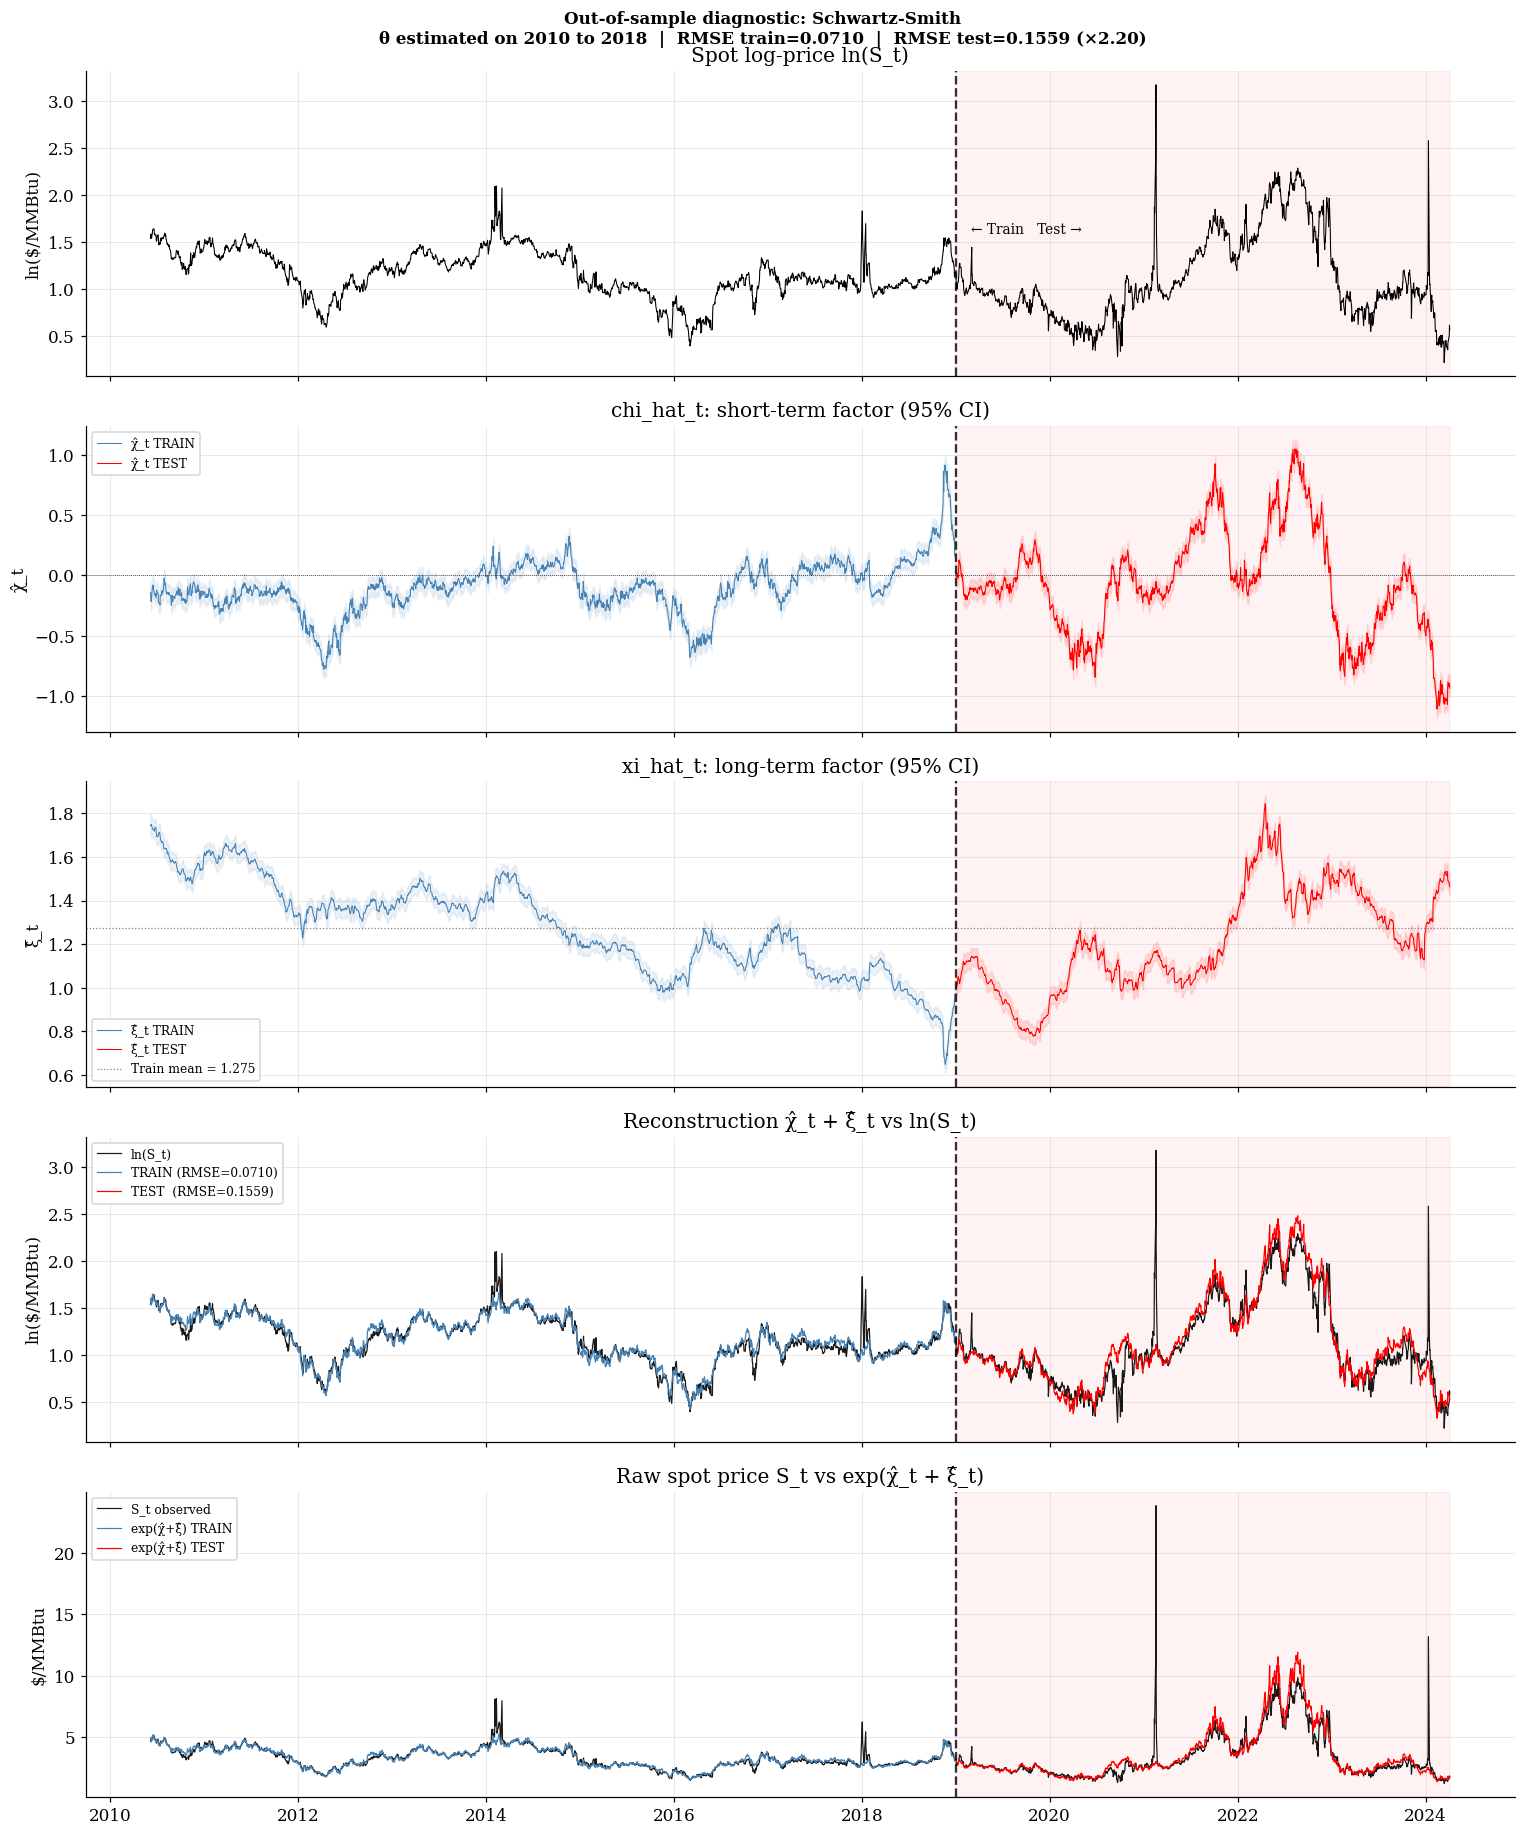

In [23]:
# ============================================================
# Full diagnostic plot
# ============================================================
fig, axes = plt.subplots(5, 1, figsize=(14, 17), sharex=True)
fig.suptitle(
    f"Out-of-sample diagnostic: Schwartz-Smith\n"
    f"θ estimated on 2010 to 2018  |  "
    f"RMSE train={rmse_train:.4f}  |  "
    f"RMSE test={rmse_test:.4f} (×{rmse_test/rmse_train:.2f})",
    fontsize=11, fontweight='bold'
)

split        = pd.Timestamp(test_start)
vline_kwargs = dict(color='black', lw=1.5, linestyle='--', alpha=0.8)
common_all   = df_natgas.index.intersection(idx_train.append(idx_test))
log_spot_all = np.log(df_natgas.loc[common_all, 'price'])
spot_all     = df_natgas.loc[common_all, 'price']

def shade_test(ax):
    ax.axvline(split, **vline_kwargs)
    ylim = ax.get_ylim()
    ax.fill_betweenx(ylim, split, common_all[-1], alpha=0.05, color='red')
    ax.set_ylim(ylim)

# Panel 1: log-spot
axes[0].plot(common_all, log_spot_all, color='black', lw=0.7)
axes[0].set_title("Spot log-price ln(S_t)")
axes[0].set_ylabel("ln($/MMBtu)")
axes[0].text(split + pd.Timedelta(days=60),
             log_spot_all.quantile(0.92), '← Train   Test →', fontsize=9)
shade_test(axes[0])

# Panel 2: chi_hat_t
for ax, df_s, P_s, idx_s, color, label in [
    (axes[1], df_train, P_train, idx_train, 'steelblue', 'TRAIN'),
    (axes[1], df_test,  P_test,  idx_test,  'red',       'TEST'),
]:
    ax.plot(idx_s, df_s['chi_hat'], color=color, lw=0.7, label=f'χ̂_t {label}')
    ax.fill_between(idx_s,
                    df_s['chi_hat'] - 1.96*np.sqrt(P_s[:,0,0]),
                    df_s['chi_hat'] + 1.96*np.sqrt(P_s[:,0,0]),
                    alpha=0.1, color=color)
axes[1].axhline(0, color='black', lw=0.5, linestyle=':')
axes[1].set_title("chi_hat_t: short-term factor (95% CI)")
axes[1].set_ylabel("χ̂_t")
axes[1].legend(fontsize=8)
shade_test(axes[1])

# Panel 3: xi_hat_t
for ax, df_s, P_s, idx_s, color, label in [
    (axes[2], df_train, P_train, idx_train, 'steelblue', 'TRAIN'),
    (axes[2], df_test,  P_test,  idx_test,  'red',       'TEST'),
]:
    ax.plot(idx_s, df_s['xi_hat'], color=color, lw=0.7, label=f'ξ̂_t {label}')
    ax.fill_between(idx_s,
                    df_s['xi_hat'] - 1.96*np.sqrt(P_s[:,1,1]),
                    df_s['xi_hat'] + 1.96*np.sqrt(P_s[:,1,1]),
                    alpha=0.1, color=color)
axes[2].axhline(df_train['xi_hat'].mean(), color='gray', lw=0.8,
                linestyle=':', label=f"Train mean = {df_train['xi_hat'].mean():.3f}")
axes[2].set_title("xi_hat_t: long-term factor (95% CI)")
axes[2].set_ylabel("ξ̂_t")
axes[2].legend(fontsize=8)
shade_test(axes[2])

# Panel 4: log reconstruction
axes[3].plot(common_all, log_spot_all, color='black', lw=0.8,
             alpha=0.9, label='ln(S_t)')
axes[3].plot(common_train, recons_train, color='steelblue', lw=0.8,
             label=f'TRAIN (RMSE={rmse_train:.4f})')
axes[3].plot(common_test,  recons_test,  color='red', lw=0.8,
             label=f'TEST  (RMSE={rmse_test:.4f})')
axes[3].set_title("Reconstruction χ̂_t + ξ̂_t vs ln(S_t)")
axes[3].set_ylabel("ln($/MMBtu)")
axes[3].legend(fontsize=8)
shade_test(axes[3])

# Panel 5: raw price
axes[4].plot(common_all, spot_all, color='black', lw=0.8,
             alpha=0.9, label='S_t observed')
axes[4].plot(common_train, np.exp(recons_train), color='steelblue',
             lw=0.8, label='exp(χ̂+ξ̂) TRAIN')
axes[4].plot(common_test,  np.exp(recons_test),  color='red',
             lw=0.8, label='exp(χ̂+ξ̂) TEST')
axes[4].set_title("Raw spot price S_t vs exp(χ̂_t + ξ̂_t)")
axes[4].set_ylabel("$/MMBtu")
axes[4].legend(fontsize=8)
axes[4].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
shade_test(axes[4])

plt.tight_layout()
plt.show()

## Conclusion

The reconstruction plot $\hat{\chi}_t + \hat{\xi}_t \approx \ln(S_t)$ is visually convincing but does not constitute a validation of the model. Indeed, the goal was not to reconstruct $\ln(S_t)$: any additive model of the form $\ln(S_t) = \chi_t + \xi_t$ will produce a good reconstruction as soon as the filter has enough flexibility to adjust the latent states.

The real goal was to **economically identify** $\chi_t$ and $\xi_t$. We wanted to extract two factors with a precise structural meaning: $\chi_t$ as a measure of short-term mean-reverting shocks, and $\xi_t$ as the long-term equilibrium level of the gas market.

However, we showed that this problem is **non-identifiable** with our data: there exists an infinite family of pairs $(\chi_t + \delta\tau_i, \xi_t - \delta\tau_i)$ for any $\delta \in \mathbb{R}$ that produce exactly the same likelihood and the same reconstruction. The filter arbitrarily picks among these solutions. $\hat{\xi}_t$ converges to the mean of the futures curve, not to the structural economic factor.

**The non-identifiability is a limitation of the data, not of the model.** It would disappear with 5 to 10 year maturity contracts (Bloomberg), for which $e^{-\gamma\tau_{\max}}$ would be significantly different from 1 and the filter would have the signal needed to separate the two factors.